## Notes (double click me)

<!-- *
In this paper we formalize the problem of causal inference as well as integration versus segregation in multisensory perception as an optimal Bayesian observer that not only infers source location from two sensory signals (visual, sV, and auditory, sA) but also whether the signals have a common cause (C).

* This inference is complicated by the fact that the nervous system does not have access to the source locations of the signals but only to noisy measurements thereof (visual, xV, and auditory, xA).

* From these noisy observations it needs to infer the best estimates of the source locations (SˆV and SˆA). All this needs to happen in the presence of uncertainnty about the presence of a common cause (C).

* The causal inference model depends on four parameters characterizing the knowledge about the environment and the observer’s sensory systems: the uncertainty of vision (sV) and audition (sA); knowledge the observer has about the spatial layout of objects, in particular how much the observer expects that objects are more likely to be located centrally (sigmaP, introduced to formalize that subjects have a bias to perceive stimuli straight ahead); and the prior probability that there is a single cause versus two causes (pcommon).

* Goal of project: The goal is now to find out the parameters by identifying the posterior distribution of those parameters given only the button presses of the simulated subject.
 -->

# Question Marks  (double click me)

<!-- 0. One Caus S, two causes Sv, Sa, and Cue Xv and Xa

1. Page 2: The optimal observer model defines how the cues might actually be combined (i.e., in a statistically optimal manner). In the model, cues are fused if the cues have one common cause and segregated if they have independent causes.

2. Page 2: This model makes three important predictions: (1) It predicts the circumstances under which subjects should perceive a common cause or independent causes. (2) It predicts if the individual cues should be fused or if they should be processed separately. (3) It predicts how the cues are combined if they are combined. Here we test the predictions of the model and analyze how well it predicts human behavior.

3. Page 3: causal inference model: pure integration (causal inference with pcommon = 1) and pure segrega- tion (causal inference with pcommon = 0).

4. Page 7: Generative model: If there is one cause (C=1), draw a position s from a normal prior distribution N(0,sigmaP), where N(m,sigmaP) stands for a normal distribution with mean m and standard deviation sigma  It is thus more likely that a stimulus is centrally located than far to the side. We then set sV =s and sA =s. If there are two causes (C=2), draw positions sV and sA each independently from N(0,sigmaP). We assume that the visual and the auditory signal are corrupted by unbiased Gaussian noise of standard deviations sV and sA, respectively and draw xV from N(sV,sV) and xA from N(sA,sA). -->

In [ ]:
!pip install emcee
!pip install corner

In [ ]:
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [ ]:
# following param are related to subject
p_common = 0.8  # prop that sv and sa come form a common cause
sigma_v = 0.6 #  noise in visual perception
sigma_a = 3.1 # noise in auditory perception
sigma_p = 15  # variance of mue_p
mue_p = 0 # represents human bias to think a source comes from a central location
N = 10000 # n_trials of the same subject.


In [ ]:
# P(xv,xa|C=1) # equation 4
likelihood_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv, xa: 1/( 2*np.pi* np.sqrt(sigma_v**2 * sigma_a**2 + sigma_v**2 * sigma_p**2 + sigma_a**2 * sigma_p**2)) \
                * np.exp(-0.5 * ((xv-xa)**2 * sigma_p**2+ (xv-mue_p)**2 * sigma_a**2 + (xa-mue_p)**2 * sigma_v**2)/(sigma_v**2 * sigma_a**2 + sigma_v**2 * sigma_p**2 + sigma_a**2 * sigma_p**2))

# P(xv,xa|C=2) # equation 6
likelihood_C2 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv, xa: 1/( 2*np.pi * np.sqrt((sigma_v**2 + sigma_p**2) * (sigma_a**2 +sigma_p**2)) ) \
                * np.exp(-0.5* ((xv-mue_p)**2/(sigma_v**2+sigma_p**2) + (xa-mue_p)**2/(sigma_a**2+sigma_p**2)))

# P(C=1|xv,xa) # equation 2
posterior_C1 = lambda p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa: likelihood_C1(sigma_v,sigma_a,sigma_p,mue_p, xv,xa) * p_common / ((likelihood_C1(sigma_v,sigma_a,sigma_p,mue_p, xv,xa)*p_common)+(likelihood_C2(sigma_v,sigma_a,sigma_p,mue_p, xv,xa) * (1-p_common))+0.000001)

# Sv^,C=2 # equation 11
sv_est_C2 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + mue_p/sigma_p**2)/(sigma_v**-2 + sigma_p**-2)
# Sa^,C=2 # equation 11
sa_est_C2 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xa/sigma_a**2 + mue_p/sigma_p**2)/(sigma_a**-2 + sigma_p**-2)
# Sv^,C=1 = Sa^,C=1 # equation 12
sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)

In [ ]:
def generate_param_space(param: tuple, func, xv: np.ndarray, xa: float, param_to_vary: str, n_vary: int, max_vary: float) -> tuple:

    """
    Calculate posterior values for a common cause model with varying parameters.

    Parameters:
    ==========
        params (tuple): A tuple containing the model parameters:
                       (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float, mue_p:float)
        func (function): The function to use for posterior calculation or estimated stimulus positions. Must be on of the following: (`posterior_C1`, `sv_est_func`, `sa_est_func`).
        xv (float): Observed value of variable V.
        xa (float): Observed value of variable A.
        param_to_vary (str): The parameter to vary. Should be one of ['p_common', 'sigma_v', 'sigma_a', 'sigma_p'].
        n_vary (int): The number of parameter values to vary.
        max_vary (float): The maximum value of the parameter to vary.

    Returns:
    =======
        tuple: A tuple containing the following arrays:
            - numpy.array: Posterior values for the specified parameter variation with the shape of (n_vary x xv).
            - numpy.array: Array of parameter values that were varied used for `p_common`. Useful for the plot legend.
            - numpy.array: Array of parameter values that were varied used for `sigma_v`, `sigma_a`, or `sigma_p`. Useful for the plot legend.

    Note:
    ====
        This function calculates the posterior values for a common cause model with a specified parameter
        (p_common, sigma_v, sigma_a, or sigma_p) varied over a range of values. It uses the provided function
        (`posterior_C1`) to calculate the posterior values, or (`sv_est_func` or `sa_est_func`) to calculate the estimated stimulus positions
        for each parameter variation.

    Example:
    =======
        p_common_vals, p_common_varies, sigma_varies = prob_common_cause(func=posterior_C1, p_common, sigma_v, sigma_a, sigma_p, mue_p, xv, xa,
                                                                        param_to_vary=`sigma_v`,
                                                                        n_vary=6,
                                                                        max_vary=10)

        # The function will calculate the posterior values (`func=posterior_C1`) for the 'sigma_v' parameter varied from 0.0 to 10.0 in 6 steps (3 values between 0 and 1 and three values between 1 and 10).
    """
    # p_common, sigma_v, sigma_a, sigma_p, mue_p = params
    p_common, sigma_v, sigma_a, sigma_p = params
    mue_p = 0

    p_common_varies = np.linspace(0, 1, n_vary).round(1)

    sigma_varies_smaller_one = np.linspace(0, 1, int(n_vary/2)).round(1)
    first_nr_greater_one = max_vary / (1 + int(n_vary/2))
    sigma_varies_greater_one = (np.linspace(first_nr_greater_one, max_vary, int(n_vary/2))).round(1)

    sigma_varies = np.sort(np.concatenate((sigma_varies_smaller_one, sigma_varies_greater_one)))

    posterior_vals = []

    for i in range(n_vary):
        if param_to_vary == 'p_common':
            posterior_vals.append(func(p_common_varies[i], sigma_v, sigma_a, sigma_p, mue_p, xv, xa))
        elif param_to_vary == 'sigma_v':
            posterior_vals.append(func(p_common, sigma_varies[i], sigma_a, sigma_p, mue_p, xv, xa))
        elif param_to_vary == 'sigma_a':
            posterior_vals.append(func(p_common, sigma_v, sigma_varies[i], sigma_p, mue_p, xv, xa))
        elif param_to_vary == 'sigma_p':
            posterior_vals.append(func(p_common, sigma_v, sigma_a, sigma_varies[i], mue_p, xv, xa))

    return np.array(posterior_vals), p_common_varies, sigma_varies


In [ ]:
def plot_param_space(params, func, xv, xa,
                           param_to_vary, n_vary, max_vary, fig_title, plot_xlabel, plot_ylabel, figsize_x, figsize_y):

  # p_common, sigma_v, sigma_a, sigma_p, mue_p = params
  p_common, sigma_v, sigma_a, sigma_p = params
  mue_p = 0
  fig, axes = plt.subplots(1, len(param_to_vary), figsize=(figsize_x, figsize_y), sharey=True)

  # Note: this is not the best way to implement this!
  # The plot function should be independent from the calculation of `prob_common_cause`,
  # thus the best is to implment this outside of the plot and feed the output of `prob_common_cause` as an argument to the plot function.
  for i, param in enumerate(param_to_vary):

    posterior_C1_vals, p_common_varies, sigma_varies = generate_param_space(params, func, xv, xa, param_to_vary=param, n_vary=6, max_vary=10)

    axes[i].plot(xv, posterior_C1_vals.T)

    if i == 0:
      axes[i].legend(p_common_varies, title=param)
    else:
      axes[i].legend(sigma_varies, title=param)

  axes[0].set_ylabel(plot_ylabel)
  fig.suptitle(fig_title)
  fig.supxlabel(plot_xlabel)
  fig.tight_layout()
  plt.show()

# Task 1.C - plotting

In [ ]:
p_common = 0.8
sigma_v = 0.6
sigma_a = 3.1
sigma_p = 15
mue_p = 0
N = 10000
params = p_common, sigma_v, sigma_a, sigma_p
xa = 0
xv = np.linspace(-20, 20, 100)

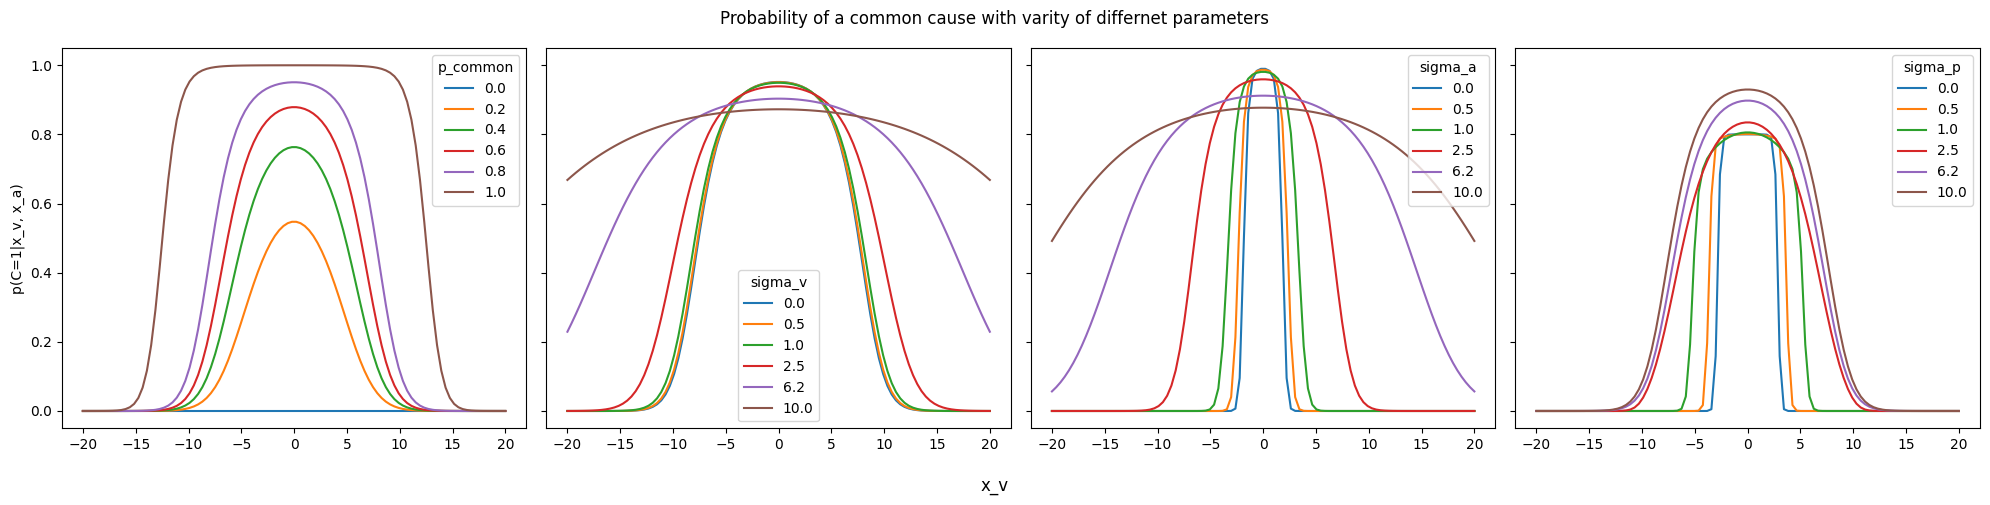

In [ ]:
# posterior_C1
plot_param_space(params, posterior_C1, xv, xa,
                       param_to_vary=['p_common', 'sigma_v', 'sigma_a', 'sigma_p'],
                       n_vary=6,
                       max_vary=10,
                       fig_title='Probability of a common cause with varity of differnet parameters',
                       plot_xlabel='x_v',
                       plot_ylabel='p(C=1|x_v, x_a)',
                       figsize_x = 20,
                       figsize_y=5)

<!-- ## Here Xa = 0, and we vary Xv while changing parameter values.
## at the left most plot we can see that the higher p_common is, the higher the probability of common cause even for high disparities between Xv and Xa.
## At the second and third plots we can see that increasing noise in auditory or visual perception lowers the propality of inferring a common cause as expected, since this higher noise will create a disparity in the estimates even in cases where original stimuli came from the same positions.
## at the right most plot, we see that increasing the variance sigma_p which represents human bias to estimate central locations for stimuli, it increases probability of inferring a common cause, since it *dilutes* this bias. -->

# Task 1.D - Plotting

In [ ]:
# Convert sv_est and sa_est to functions
sv_est_func = lambda p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa : posterior_C1(p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa) * sv_sa_est_C1(sigma_v,sigma_a,sigma_p,mue_p, xv,xa) + (1-posterior_C1(p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa)) * sv_est_C2( sigma_v,sigma_a,sigma_p,mue_p, xv,xa)
sa_est_func = lambda p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa : posterior_C1(p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa) * sv_sa_est_C1(sigma_v,sigma_a,sigma_p,mue_p, xv,xa) + (1-posterior_C1(p_common,sigma_v,sigma_a,sigma_p,mue_p, xv,xa)) * sa_est_C2( sigma_v,sigma_a,sigma_p,mue_p, xv,xa)


<ipython-input-14-331b717f88cd>:17: RuntimeWarning: divide by zero encountered in true_divide
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:17: RuntimeWarning: divide by zero encountered in double_scalars
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:17: RuntimeWarning: invalid value encountered in true_divide
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:13: RuntimeWarning: divide by zero encountered in true_divide
  sv_est_C2 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + mue_p/sigma_p**2)/(sigma_v**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:

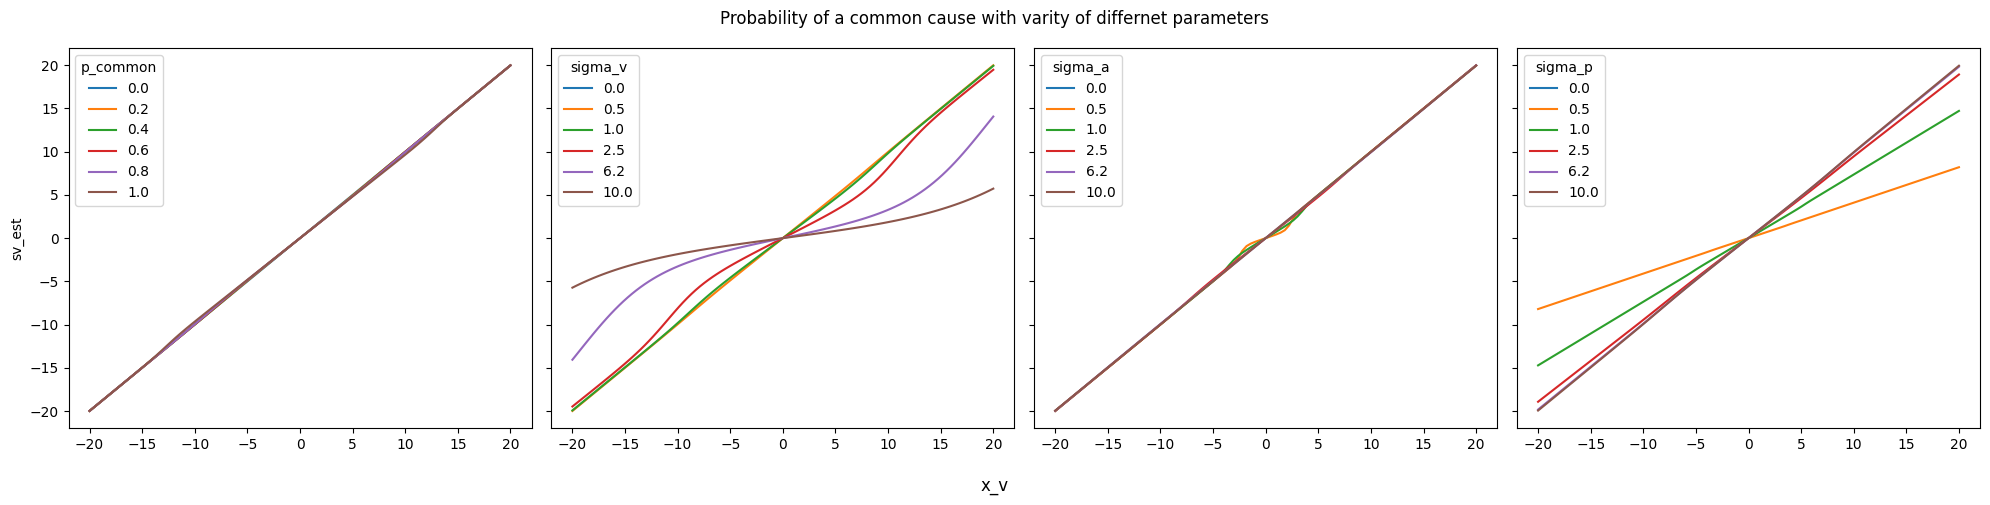

In [ ]:
# sv_est_func
plot_param_space(params, sv_est_func, xv, xa,
                       param_to_vary=['p_common', 'sigma_v', 'sigma_a', 'sigma_p'],
                       n_vary=6,
                       max_vary=10,
                       fig_title='Probability of a common cause with varity of differnet parameters',
                       plot_xlabel='x_v',
                       plot_ylabel='sv_est',
                       figsize_x = 20,
                       figsize_y=5)

<!-- # in this plot we plot the percieved location of visual stimuli X_v vs the estimated position of visual stimuli S_v, while varying our paramters.
## from left-most to right most:
## first plot: the effect of p_common is not visible in this plot.
## second plot: increasing noise in visual perception creates higher missmatch between X_v and S_v.  
## third plot: changing noise in auditory perception (sigma_a)  has nigligible effect on the estimation since it's much higher than noise in visual perception (sigma_v).
## fourth plot: a lower sigma_p represents a stronger bias for humans to estimate central locations for stimuli, which is present here as this lower slope for lower values of sigma_p. -->

<ipython-input-14-331b717f88cd>:17: RuntimeWarning: divide by zero encountered in true_divide
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:17: RuntimeWarning: divide by zero encountered in double_scalars
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:17: RuntimeWarning: invalid value encountered in true_divide
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**-2)
<ipython-input-14-331b717f88cd>:17: RuntimeWarning: invalid value encountered in double_scalars
  sv_sa_est_C1 = lambda sigma_v,sigma_a,sigma_p,mue_p, xv,xa: (xv/sigma_v**2 + xa/sigma_a**2 + mue_p/sigma_p**2)/ (sigma_v**-2 + sigma_a**-2 + sigma_p**

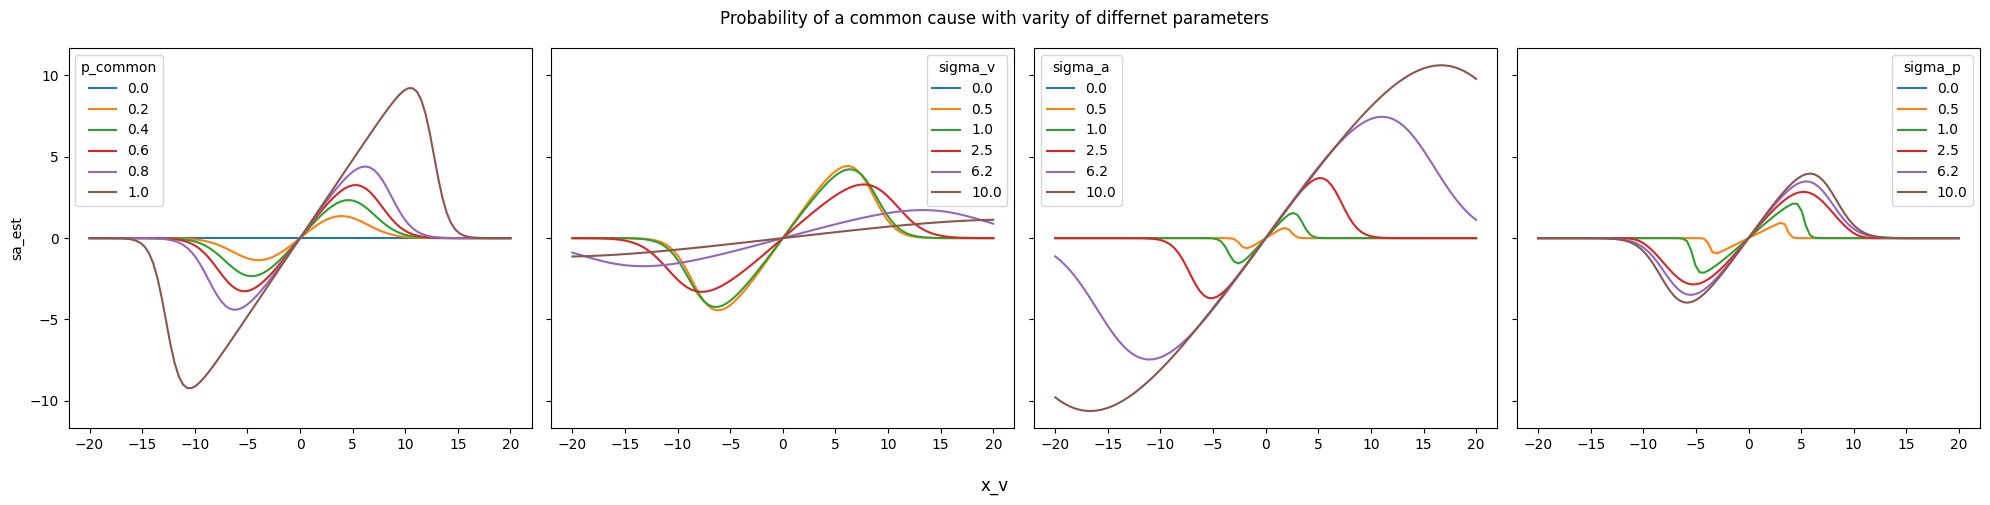

In [ ]:
# sa_est_func
plot_param_space(params, sa_est_func, xv, xa,
                       param_to_vary=['p_common', 'sigma_v', 'sigma_a', 'sigma_p'],
                       n_vary=6,
                       max_vary=10,
                       fig_title='Probability of a common cause with varity of differnet parameters',
                       plot_xlabel='x_v',
                       plot_ylabel='sa_est',
                       figsize_x = 20,
                       figsize_y=5)

<!-- # Here auditory percepts X_a are set to zero, and we plot estimated auditory stimuli position against visual percepts X_v.
## in the left most plot we see that the higher p_common is, S_a leans towards X_v values (the subject estimates auditory stimuli from where it thinks the visual stimuli was present). this reflects the fact that we have more confidence in our visual perception since it has lower noise.
## in the second plot: increasing noise in visual perception for p_common = 0.8, comparing to previous plot, we see that it decreases the relationship in previous plot, since we have less confidence in visual perception when it has higher noise.
## third plot:  increasing sigma_a while p_common = 0.8, sa_est tends to have same values as X_v, even for high disparities between X_V and X_a (which is set to zero). -->


## Q2.a,b: implement make_button_presses and use it to generate expiremntal data.

In [ ]:
def make_button_presses(N, params):
    """
    Paramters:
    =========
      N: tbc.
      params (tuple): A tuple containing the model parameters:
                      (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float)
    """
    # p_common, sigma_v, sigma_a, sigma_p, mue_p = params
    p_common, sigma_v, sigma_a, sigma_p = params
    mue_p = 0

    # Generate pairs of sv,sa
    s_vals = np.array([-12, -6, 0, 6, 12])
    num_pairs = len(s_vals) ** 2
    reps = N // num_pairs
    sv_sa = np.array(list(product(s_vals, repeat=2)))

    sv_sa_array = np.repeat(sv_sa, reps, axis=0)
    labels = np.repeat(list(range(1, num_pairs+1)), reps, axis = 0)

    # Add noise to them to optain xv and xa.
    xv = sv_sa_array[:, 0] + np.random.normal(0, sigma_v, size=N)
    xa = sv_sa_array[:, 1] + np.random.normal(0, sigma_a, size=N)

    # estimate Sv^, Sa^, using equations 9, 10
    posterior_c1 = posterior_C1(p_common, sigma_v, sigma_a, sigma_p, mue_p, xv, xa)
    sv_sa_est_c1 = sv_sa_est_C1(sigma_v, sigma_a, sigma_p, mue_p, xv, xa)
    sv_est_c2 = sv_est_C2(sigma_v, sigma_a, sigma_p, mue_p, xv, xa)
    sa_est_c2 = sa_est_C2(sigma_v, sigma_a, sigma_p, mue_p, xv, xa)

    sv_est = posterior_c1 * sv_sa_est_c1 + (1 - posterior_c1) * sv_est_c2
    sa_est = posterior_c1 * sv_sa_est_c1 + (1 - posterior_c1) * sa_est_c2

    # Divide Sv^, Sa^ into 5 bins corresponding to button presses
    bins = [-float('inf'), -9, -3, 3, 9, float('inf')]
    sv_button_presses = np.digitize(sv_est, bins)
    sa_button_presses = np.digitize(sa_est, bins)


    sa_button_press_counts, _, _ = np.histogram2d(labels, sa_button_presses, bins=(np.arange(1, num_pairs+2), np.arange(1, 7)))
    sa_button_press_counts = sa_button_press_counts.astype(int)

    sv_button_press_counts, _, _ = np.histogram2d(labels, sv_button_presses, bins=(np.arange(1, num_pairs+2), np.arange(1, 7)))
    sv_button_press_counts = sv_button_press_counts.astype(int)

    results_dict = {
        'sv_sa_pairs': sv_sa_array,
        'xv': xv,
        'xa': xa,
        'sv_est': sv_est,
        'sa_est': sa_est,
        'sv_button_presses': sv_button_presses,
        'sa_button_presses': sa_button_presses,
        'sa_button_press_counts': sa_button_press_counts,
        'sv_button_press_counts': sv_button_press_counts,
        'labels': labels
    }

    return results_dict


In [ ]:

exp_data = make_button_presses(N, params)

## Q2.C: Implement the log-likelihood function from eq-16.
## Q2.D: Test this new function using a set of parameters different from those used to generate the experimental data

In [ ]:
def log_likelihood(exp_data,N, params):
    """
    Paramters:
    =========
      exp_data: tbc.
      N: tbc.
      params (tuple): A tuple containing the model parameters:
                      (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float)
    """
    model_data = make_button_presses(N*10, params)

    sv_log_pi_model = np.log(model_data['sv_button_press_counts']/(N*10))
    sv_LL = np.sum(exp_data['sv_button_press_counts'] * sv_log_pi_model)

    sa_log_pi_model = np.log(model_data['sa_button_press_counts']/(N*10))
    sa_LL = np.sum(exp_data['sa_button_press_counts'] * sa_log_pi_model)
    return sa_LL + sv_LL
    # calc ni and pi and LL
    #return LL
log_likelihood(exp_data,N, params)

<ipython-input-24-e38726f8074c>:12: RuntimeWarning: divide by zero encountered in log
  sv_log_pi_model = np.log(model_data['sv_button_press_counts']/(N*10))
<ipython-input-24-e38726f8074c>:13: RuntimeWarning: invalid value encountered in multiply
  sv_LL = np.sum(exp_data['sv_button_press_counts'] * sv_log_pi_model)
<ipython-input-24-e38726f8074c>:15: RuntimeWarning: divide by zero encountered in log
  sa_log_pi_model = np.log(model_data['sa_button_press_counts']/(N*10))
<ipython-input-24-e38726f8074c>:16: RuntimeWarning: invalid value encountered in multiply
  sa_LL = np.sum(exp_data['sa_button_press_counts'] * sa_log_pi_model)


nan

In [ ]:
log_likelihood(exp_data,N, [0.2,5,0.4,3])

<ipython-input-24-e38726f8074c>:12: RuntimeWarning: divide by zero encountered in log
  sv_log_pi_model = np.log(model_data['sv_button_press_counts']/(N*10))
<ipython-input-24-e38726f8074c>:13: RuntimeWarning: invalid value encountered in multiply
  sv_LL = np.sum(exp_data['sv_button_press_counts'] * sv_log_pi_model)
<ipython-input-24-e38726f8074c>:15: RuntimeWarning: divide by zero encountered in log
  sa_log_pi_model = np.log(model_data['sa_button_press_counts']/(N*10))
<ipython-input-24-e38726f8074c>:16: RuntimeWarning: invalid value encountered in multiply
  sa_LL = np.sum(exp_data['sa_button_press_counts'] * sa_log_pi_model)


nan

<!-- ## Q2.D:  Look at numerical aspects, e.g. NaN & Infty. Why do they appear in the calculation of the likelihood? What does this tell you about the shape of the likelihood in the parameter space? Does this have implications for using gradient-based approaches to fit the model? Consider adding a tiny epsilon to pi in Eq. 16. What effect does this have and why is this desirable?

### NaN and Infinity appear because of the log present in equation 16, since it is a log of a probability wich takes the range (0,1).
### from the NaN values in the log-likelihood we can tell it approaches negative infinity when Pi approaches zero, it is a non-convex function with discontinuoties.
### using gradient approaches is not a good idea, since the function is non-convex and has discontinueties.
### adding epsilon will solve the numerical instability caused by the log, so we will not encounter NaN, which is desirable. -->

In [ ]:
def eps_log_likelihood(exp_data,N, params):
    """
    Paramters:
    =========
      exp_data: tbc.
      N: tbc.
      params (tuple): A tuple containing the model parameters:
                      (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float)
    """
    model_data = make_button_presses(N*10, params)
    epsilon = 0.000001
    sv_log_pi_model = np.log(model_data['sv_button_press_counts']/(N*10) +epsilon)
    sv_LL = np.sum(exp_data['sv_button_press_counts'] * sv_log_pi_model)

    sa_log_pi_model = np.log(model_data['sa_button_press_counts']/(N*10)+epsilon)
    sa_LL = np.sum(exp_data['sa_button_press_counts'] * sa_log_pi_model)


    return sa_LL + sv_LL
    # calc ni and pi and LL
    #return LL

eps_log_likelihood(exp_data,N, params)

-70961.04156230464

In [ ]:
eps_log_likelihood(exp_data,N, [0.2,5,0.4,3])

-153753.9403421252

## Q2.e: sample the paramter space to find the best model.


In [ ]:
def ll_param_space_search(exp_data,N, p_common_range = [0,1],sigma_v_range = [0,20],sigma_a_range=[0,20],sigma_p_range=[0,20],samples_per_axis = 10):
    p_common = np.linspace(p_common_range[0],p_common_range[1],samples_per_axis)
    sigma_v = np.linspace(sigma_v_range[0]+0.001,sigma_v_range[1],samples_per_axis)
    sigma_a = np.linspace(sigma_a_range[0]+0.001,sigma_a_range[1],samples_per_axis)
    sigma_p = np.linspace(sigma_p_range[0]+0.001,sigma_p_range[1],samples_per_axis)

    # Create a meshgrid
    p_common_mesh, sigma_v_mesh, sigma_a_mesh, sigma_p_mesh = np.meshgrid(p_common, sigma_v, sigma_a, sigma_p, indexing='ij')

    # Reshape
    models = np.column_stack([p_common_mesh.flatten(), sigma_v_mesh.flatten(), sigma_a_mesh.flatten(), sigma_p_mesh.flatten()])

    # Apply eps_log_likelyhood to all rows at once, to decrease runtime.
    log_likelihoods = np.apply_along_axis(lambda row: eps_log_likelihood(exp_data, N, row), axis=1, arr=models)
    # Get best model index (highest LL)
    best_model_idx = np.argmax(log_likelihoods)

    return log_likelihoods, models, best_model_idx


In [ ]:
log_likelihoods, models, best_model_idx = ll_param_space_search(exp_data,N)
best_model = models[best_model_idx,:]

In [ ]:
print('best model params by LL: {0}, {1}, {2}, {3}'.format(best_model[0],best_model[1],best_model[2],best_model[3],))
print('actual model for expiremental data: {0}, {1}, {2}, {3}'.format(p_common,sigma_v,sigma_a,sigma_p))

best model params by LL: 0.5555555555555556, 0.001, 4.445222222222222, 13.333666666666664
actual model for expiremental data: 0.8, 0.6, 3.1, 15


## Q2.e: Plot the marginal likelihoods with respect to each parameter, and indicatethe global max-likelihood values.

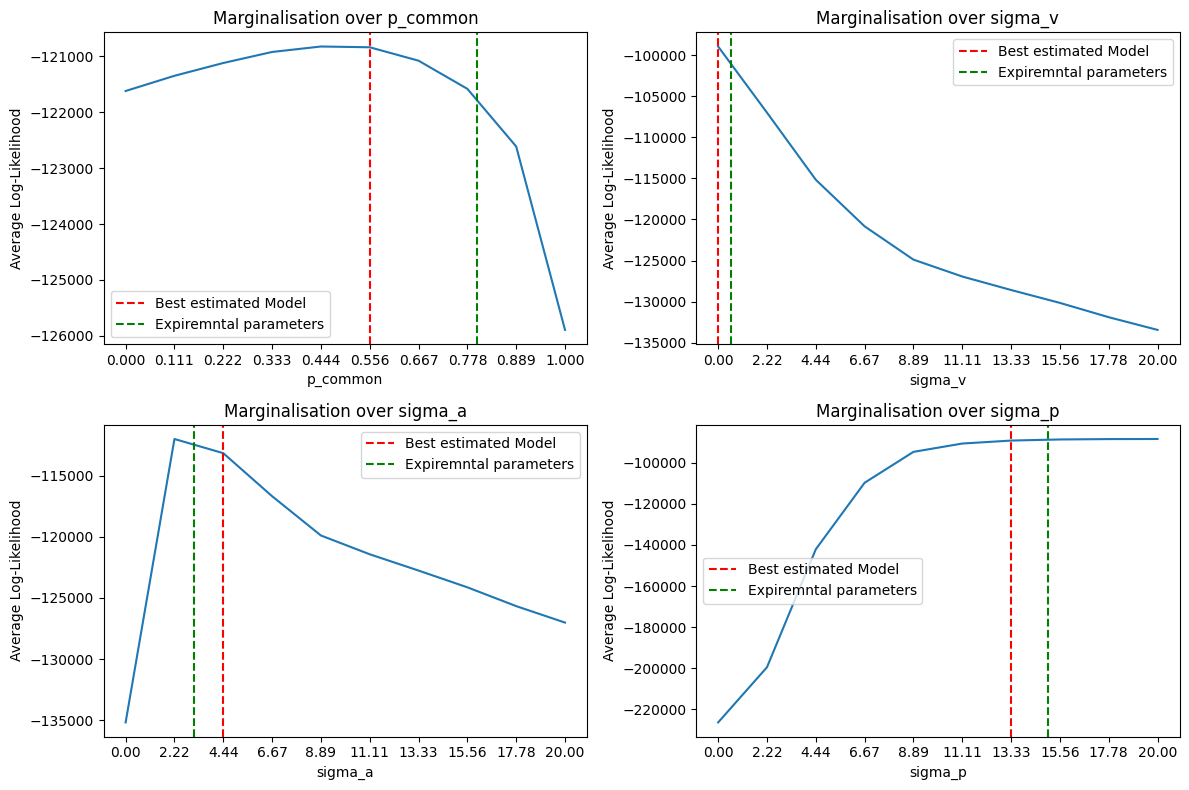

In [ ]:

def marginal_plots(log_likelihoods, models, best_model_idx, params, p_common_range=[0, 1], sigma_v_range=[0, 20], sigma_a_range=[0, 20], sigma_p_range=[0, 20], samples_per_axis=10):
    # Reshape into 4d array to seperate LL values corresponding to each of the 4 parameters
    log_likelihoods_4D = log_likelihoods.reshape(samples_per_axis, samples_per_axis, samples_per_axis, samples_per_axis)

    # Calculate the average log-likelihood for each unique value of p_common
    avg_log_likelihoods_p_common = np.mean(log_likelihoods_4D, axis=(1, 2, 3))

    # Calculate the average log-likelihood for each unique value of sigma_v
    avg_log_likelihoods_sigma_v = np.mean(log_likelihoods_4D, axis=(0, 2, 3))

    # Calculate the average log-likelihood for each unique value of sigma_a
    avg_log_likelihoods_sigma_a = np.mean(log_likelihoods_4D, axis=(0, 1, 3))

    # Calculate the average log-likelihood for each unique value of sigma_p
    avg_log_likelihoods_sigma_p = np.mean(log_likelihoods_4D, axis=(0, 1, 2))


    # Get the best model paramters
    best_model = models[best_model_idx, :]

    # Plotting
    param_names = ['p_common', 'sigma_v', 'sigma_a', 'sigma_p']
    param_ranges = [p_common_range, sigma_v_range, sigma_a_range, sigma_p_range]
    avg_ll = [avg_log_likelihoods_p_common,avg_log_likelihoods_sigma_v,avg_log_likelihoods_sigma_a,avg_log_likelihoods_sigma_p]

    plt.figure(figsize=(12, 8))
    for i, param_name in enumerate(param_names):
        plt.subplot(2, 2, i + 1)
        plt.plot(np.linspace(param_ranges[i][0], param_ranges[i][1], samples_per_axis), avg_ll[i])
        plt.axvline(x=best_model[i], color='red', linestyle='--', label='Best estimated Model')
        plt.axvline(x=params[i], color='green', linestyle='--', label='Expiremntal parameters')
        plt.xlabel(param_name)
        plt.ylabel('Average Log-Likelihood')
        plt.title(f'Marginalisation over {param_name}')
        plt.legend()
        plt.xticks(np.linspace(param_ranges[i][0], param_ranges[i][1], samples_per_axis))

    plt.tight_layout()

params = [p_common, sigma_v, sigma_a, sigma_p]
marginal_plots(log_likelihoods, models, best_model_idx, params)

# Task 2.f

In [ ]:
def log_prior(params, min=0.0, max=20.0):
    """
    Calculate the log-prior probability for a common cause model with specified parameter bounds.

    Parameters:
    ==========
        params (tuple): A tuple containing the model parameters:
                        (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float, mue_p:float)
        min (float, optional): Minimum allowed value for all parameters. Default is 0.0.
        max (float, optional): Maximum allowed value for all parameters. Default is 20.0.

    Returns:
    =======
        float: The log-prior probability for the specified parameter values within the given bounds.

    Note:
    ====
        This function calculates the log-prior probability for a common cause model with specified parameter values.
        The parameter values are checked against the specified bounds (default: min=0.0, max=20.0).

        A log-prior of 0 means that all parameter values within the bounds are equally likely,
        which is the characteristic of a uniform prior.
        If any of the parameter values fall outside the specified bounds, it implies that those parameter values are not allowed in the prior distribution.
        In this case, we return -np.inf, which corresponds to the natural logarithm of 0. A log-prior of negative infinity indicates that
        the parameter values are not allowed and should be excluded from the posterior calculation.

        A rectangular prior is a type of prior probability distribution that assigns equal probability to all values within a specific range,
        while assigning zero probability to values outside that range.
        It is called "rectangular" because the probability density function (PDF) has a constant value (rectangle) within the defined range
        and is zero outside that range.

    Example:
    =======
        >>> p_common, sigma_v, sigma_a, sigma_p, mue_p = 0.8, 0.6, 3.1, 15, 0
        >>> params = (p_common, sigma_v, sigma_a, sigma_p)
        >>> log_prior(params, min=0.1, max=10)
        >>> -inf
    """
    # p_common, sigma_v, sigma_a, sigma_p, mue_p = params
    p_common, sigma_v, sigma_a, sigma_p = params
    mue_p = 0

    # Override param
    min = 1E-10
    max = 20

    # Define parameter bounds
    p_common_min, p_common_max = 1E-5, 1.0
    sigma_v_min, sigma_v_max = min, max
    sigma_a_min, sigma_a_max = min, max
    sigma_p_min, sigma_p_max = min, max
    # mue_p_min, mue_p_max = -max, max

    # Check if the parameters fall within the bounds
    # TODO: check if we should exclude the bounderies?
    if (p_common_min < p_common < p_common_max) and \
       (sigma_v_min < sigma_v < sigma_v_max) and \
       (sigma_a_min < sigma_a < sigma_a_max) and \
       (sigma_p_min < sigma_p < sigma_p_max): #and \
      #  (mue_p_min < mue_p < mue_p_max):
        return 0.0  # log(1) = 0, indicating a uniform prior
    else:
        return -np.inf  # log(0) = -inf, indicating an invalid parameter value

# Test
p_common, sigma_v, sigma_a, sigma_p = 0.8, 0.6, 3.1, 15
params = (p_common, sigma_v, sigma_a, sigma_p)
log_prior(params, min=0.1, max=20)


0.0

In [ ]:
def log_posterior(params: tuple, N:int, func:str, data: dict) -> float:
    """
    Calculate the logarithm of the posterior probability.

    Parameters:
    ==========
        params (tuple): A tuple containing the model parameters.
        N (int): Number of samples in the experimental data.
        func (function): The function to use for posterior calculation (e.g., `posterior_C1`, `sv_est_func`, or `sa_est_func`).
        data (dict): Experimental data that is generated after calling `make_button_presses(N, params)`.
                     The dictionary must have the keys: `sa_button_press_counts` and `sv_button_press_counts`.

    Returns:
    =======
        float: The logarithm of the posterior probability.

    Notes:
    =====
        The logarithm of the posterior is used instead of the posterior itself to avoid numerical underflow,
        as posterior probabilities can be very small numbers.

        The function checks if the log-prior is equal to negative infinity (i.e., an invalid parameter value).
        If the parameter values fall outside the defined bounds, the function returns negative infinity,
        indicating that these parameter values are not allowed.
        If the parameter values are within the bounds, the function proceeds to calculate the log-likelihood.

        The log-posterior is computed as the sum of the log-prior and log-likelihood.

        The log-posterior provides a measure of the goodness of fit between the model and the observed data,
        taking into account our prior beliefs about the parameter values.
        By maximizing the log-posterior with respect to the parameter values using Markov Chain Monte Carlo (MCMC) sampling,
        we can obtain estimates of the most likely parameter values that explain the observed data.

    Example:
    =======
        >>> p_common, sigma_v, sigma_a, sigma_p, mue_p = 0.8, 0.6, 3.1, 15, 0
        >>> params = (p_common, sigma_v, sigma_a, sigma_p, mue_p)
        >>> log_posterior(params, N, eps_log_likelihood, exp_data)
        >>> -71070.65697551613

    """
    # Calculate the log-prior probability
    log_prior_val = log_prior(params)

    # Check if the parameter values are within bounds (faster!)
    if log_prior_val == -np.inf:
        return -np.inf  # Invalid parameter values, return log(0) = -inf

    # Calculate the log-likelihood using the provided function
    log_likelihood_val = func(data, N, params)

    # Calculate the log-posterior as the sum of log-prior and log-likelihood
    # posterior ~ prior * likelihood <==> log(posterior) = log(prior) + log(likelihood)
    log_posterior_val = log_prior_val + log_likelihood_val

    return log_posterior_val


# Test
p_common, sigma_v, sigma_a, sigma_p = 0.8, 0.6, 3.1, 15
params = (p_common, sigma_v, sigma_a, sigma_p)
log_posterior_val = log_posterior(params, N, eps_log_likelihood, exp_data)
log_posterior_val

-70963.88459378725

In [ ]:
def mcmc_fit(params, N:int, func:str, data:dict, n_walkers:int, n_step:int, n_params, min_bound=0.0, max_bound=20.0) -> np.ndarray:
    """
    Fit a common cause model to experimental data using MCMC sampling.

    Parameters:
    ==========
        params (tuple): A tuple containing the model 5 parameters:
                        (p_common:float, sigma_v:float, sigma_a:float, sigma_p:float, mue_p:float)
        N (int): Number of samples in the experimental data.
        func (function): The function to use for posterior calculation or estimated stimulus positions (e.g. eps_log_likelihood).
        data (dict): Experimental data that is generated after calling `make_button_presses(N, params)`.
                     The dictionary must have the keys: `sa_button_press_counts` and `sv_button_press_counts`.
        n_walkers (int): Number of walkers (chains) in the MCMC sampling. It determines the number of independent
                         MCMC chains that explore the parameter space simultaneously.
        n_steps (int): Number of MCMC steps to be taken by each walker.
                       It specifies the dimensionality of the parameter space for the model.
        n_params (int): The number of parameters to be estimated in the model.

        min_bound (float, optional): Minimum allowed value for all parameters. Default is 0.0.
        max_bound (float, optional): Maximum allowed value for all parameters. Default is 20.0.

    Returns:
    =======
        np.ndarray: The MCMC samples with the shape
                    The shape of the array is (n_walkers x n_params) # TODO: double check this again!
    Notes:
    =====
        The MCMC fit aims to find the posterior distribution of the model parameters given the experimental data.
        The MCMC algorithm samples from the posterior distribution using the provided likelihood function (`func`)
        and the prior function (`log_prior`).

        # n_walkers:
        The number of walkers represents how many independent chains will explore the parameter space simultaneously.
        Having more walkers allows for better exploration of the posterior distribution and reduces the risk of getting
        stuck in local minima. A common rule of thumb is to use at least twice the number of model parameters for `n_walkers`.
        So, if we have 5 model parameters, a reasonable starting value for n_walkers could be 10 or more.
        More walkers also increase the computational cost, so it's essential to balance the number of walkers
        based on the available computational resources.

        # n_steps:
        The number of steps is the total number of iterations each walker takes during the MCMC sampling.
        It determines the length of the MCMC chain and the number of samples obtained.
        A higher `n_steps` value allows for better exploration of the parameter space and reduces the impact of
        initial conditions, leading to more reliable estimates of the posterior distribution.
        A common practice is to set `n_steps` to a value large enough to ensure that the chains have converged
        to the stationary posterior distribution. A typical starting value for `n_steps` could be 1000, but in practice,
        a few thousand or even tens of thousands of steps may be necessary to achieve convergence,
        depending on the complexity of the model and the data.

        MCMC sampler is particularly well-suited for high-dimensional parameter spaces.
        Check out this tutorial for more informations: https://emcee.readthedocs.io/en/stable/tutorials/line/#

    Example:
    =======
        >>> # Generate experimental data
        >>> p_common, sigma_v, sigma_a, sigma_p = 0.8, 0.6, 3.1, 15, 0
        >>> params = (sigma_v, sigma_a, sigma_p)
        >>> exp_data = make_button_presses(N, params)

        >>> # Set the number of walkers and steps
        >>> n_walkers = 10
        >>> n_steps = 1000
        >>> n_params = len(params)  # = 5

        >>> # Perform the MCMC fit
        >>> samples = mcmc_fit(params, N, likelihood_func, exp_data, n_walkers, n_steps, n_params)
    """
    p_common, sigma_v, sigma_a, sigma_p = params

    # Initialize the walkers with random parameter values within the bounds
    initial_guesses = np.random.uniform(1E-10, max_bound, size=(n_walkers, n_params))
    initial_guesses[:, 0] = np.random.uniform(1E-10, 1, size=(n_walkers))

    # Create the MCMC sampler using the `emcee` library
    sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior, args=(N, func, data))

    # Run the MCMC sampling
    pos, prob, state = sampler.run_mcmc(initial_guesses, n_steps)

    # Flatten the chain for further analysis
    samples = sampler.get_chain(discard=10, flat=True)
    # samples = sampler.flatchain

    return samples


In [ ]:
p_common = 0.8
sigma_v = 0.6
sigma_a = 3.1
sigma_p = 15
mue_p = 0
N = 10_000

params = (p_common, sigma_v, sigma_a, sigma_p)

experimental_dataset1 = make_button_presses(N, params)

n_walkers = 20
n_steps = 1000
# TODO: should we consider all paramters? Including mue_p??
n_params = len(params) # = 5: p_common, sigma_v, sigma_a, sigma_p, mue_p

# Perform the MCMC fit
samples_dataset1 = mcmc_fit(params, N, eps_log_likelihood, experimental_dataset1, n_walkers, n_steps, n_params)
samples_dataset1.shape

(19800, 4)

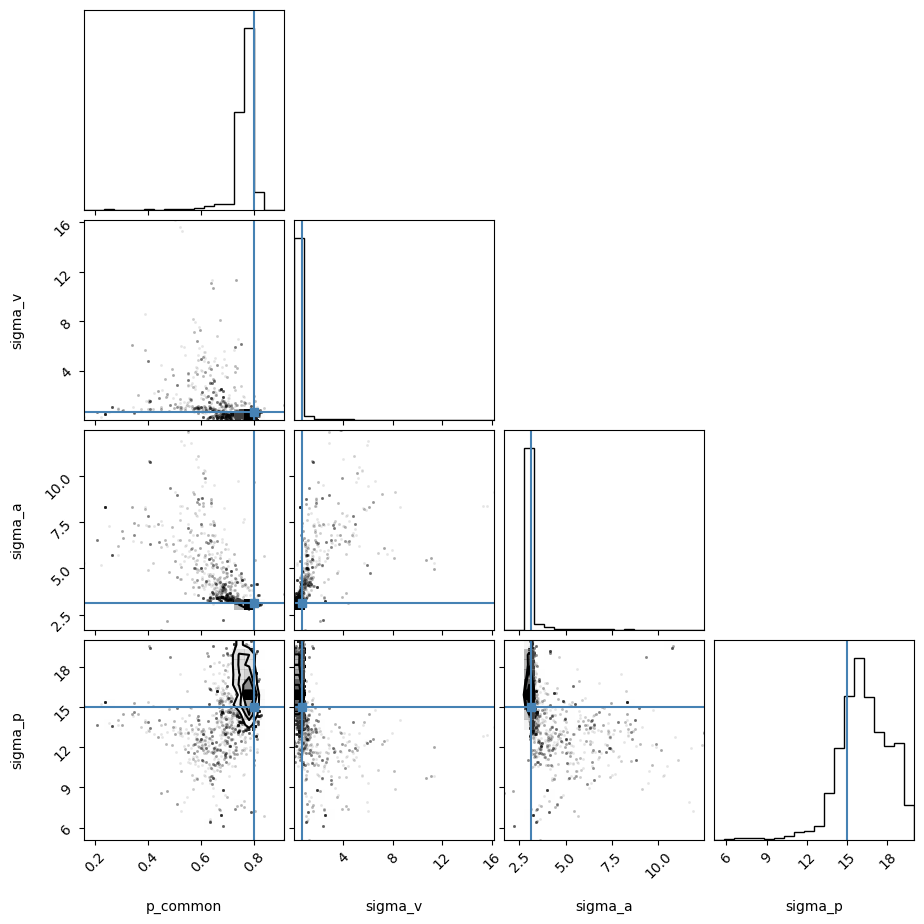

In [ ]:
# Plotting the results
# https://corner.readthedocs.io/en/latest/pages/custom/
param_labels = ['p_common', 'sigma_v', 'sigma_a', 'sigma_p']
# corner_plot = corner.corner(samples_dataset1, labels=param_labels, show_titles=True, truths=params)
corner_plot = corner.corner(samples_dataset1, labels=param_labels,truths=params)
corner_plot.show()

# Task 2.g

In [ ]:
mean_params = np.mean(samples_dataset1, axis=0)

print("Parameters:", params)

print("\nMean Parameters:")
print("p_common:", mean_params[0])
print("sigma_v:", mean_params[1])
print("sigma_a:", mean_params[2])
print("sigma_p:", mean_params[3])
# print("mue_p:", mean_params[4])

Parameters: (0.8, 0.6, 3.1, 15)

Mean Parameters:
p_common: 0.7582119411891489
sigma_v: 0.5647899427134542
sigma_a: 3.278289243498304
sigma_p: 16.24813376356683


# Task 2.h

In [ ]:
# Parameters for subject 1
p_common_1 = 0.3
sigma_v_1 = 2.1
sigma_a_1 = 9
sigma_p_1 = 12
mue_p_1 = 0
params_1 = p_common_1, sigma_v_1, sigma_a_1, sigma_p_1

# Parameters for subject 2
p_common_2 = 0.3
sigma_v_2 = 2.1
sigma_a_2 = 2
sigma_p_2 = 12
mue_p_2 = 0
params_2 = p_common_2, sigma_v_2, sigma_a_2, sigma_p_2

# Generate data for subject 1
data_subject_1 = make_button_presses(int(N/2), params_1)

# Generate data for subject 2
data_subject_2 = make_button_presses(int(N/2), params_2)

combined_data = {}
combined_data['sv_button_press_counts'] = data_subject_1['sv_button_press_counts'] + data_subject_2['sv_button_press_counts']
combined_data['sa_button_press_counts'] = data_subject_1['sa_button_press_counts'] + data_subject_2['sa_button_press_counts']

# Fit the model to the combined data using MCMC
n_walkers = 20  # 100
n_steps = 1000 # 1000
n_params = 4
# params, N, eps_log_likelihood, exp_data, n_walkers, n_steps

samples_combined = mcmc_fit(params, N, eps_log_likelihood, combined_data, n_walkers, n_steps, n_params)

samples_combined.shape

(19800, 4)

In [ ]:
mean_params = np.mean(samples_combined, axis=0)

print("Parameters:", params)

print("\nMean Parameters:")
print("p_common:", mean_params[0])
print("sigma_v:", mean_params[1])
print("sigma_a:", mean_params[2])
print("sigma_p:", mean_params[3])
# print("mue_p:", mean_params[4])

Parameters: (0.8, 0.6, 3.1, 15)

Mean Parameters:
p_common: 0.2746334543150333
sigma_v: 2.2576940312351454
sigma_a: 5.743942284015364
sigma_p: 13.18611853594552


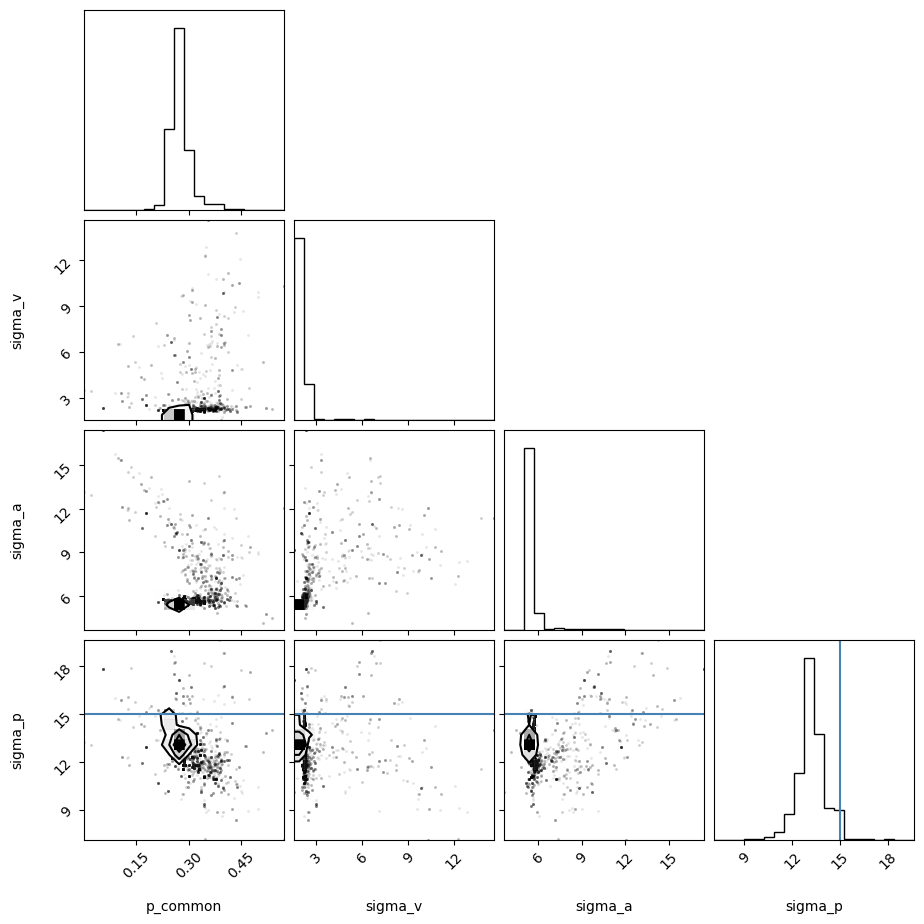

In [ ]:
corner_plot = corner.corner(samples_combined, labels=param_labels,truths=params)
corner_plot.show()